In [3]:
from src.dataset import load_dataset
from regression.polynomial_regression import PolynomialRegression
from regression.probabilistic_rf_scoring import plot_pdf_with_true_target,fit_rank_pdfs_loglik, plot_ranked_pdfs
import matplotlib.pyplot as plt
from dataset import save_processed_dataset
import os
import joblib
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from regression.probabilistic_rf_scoring import get_regression_score
plt.style.use("default")
from plot_style import set_plot_style
set_plot_style()

In [4]:
TRAIN_PATH_FULL="../../../../data/processed/full_train/train.csv"
TRAIN_PATH_SPLIT= "../../../../data/processed/split_85_15/train_85.csv"
TEST_PATH_SPLIT= "../../../../data/processed/split_85_15/test_15.csv"
OUTPUT_PATH= "../../../../output/polynomial_regression/model_target/"
MODEL_PATH="polynomial_regression_model_target.pkl"
RESIDUI_CSV="residui.csv"
ITERATIONS = 1000
TARGET_COL = "trq_target"
FEUTURE=["trq_measured","mgt","ias","oat","np_ng_ratio","pa"]
DEGREE = (1,2,3)

In [5]:
train_df = load_dataset(TRAIN_PATH_SPLIT)
test_df = load_dataset(TEST_PATH_SPLIT)


X_train = train_df[FEUTURE].values
y_train = train_df[TARGET_COL].values

X_test = test_df[FEUTURE].values
y_test = test_df[TARGET_COL].values


Degree  1
MAE: 0.1849696331955001
MSE: 0.0653116873993568
RMSE: 0.2555615139244499
R²: 0.9996772304016452


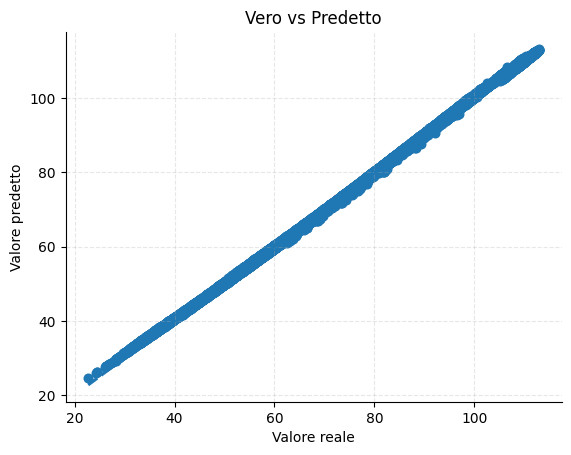


Degree  2
MAE: 0.021049430276294308
MSE: 0.001331155387866703
RMSE: 0.036485002231967906
R²: 0.9999934214455789


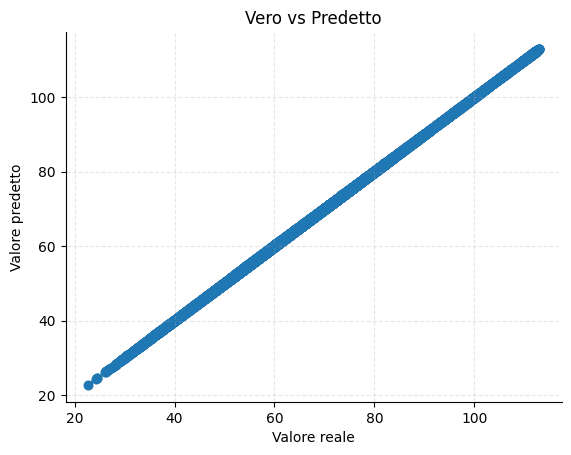


Degree  3
MAE: 0.017072748387306772
MSE: 0.0008022632573286177
RMSE: 0.028324252105371074
R²: 0.9999960352243273


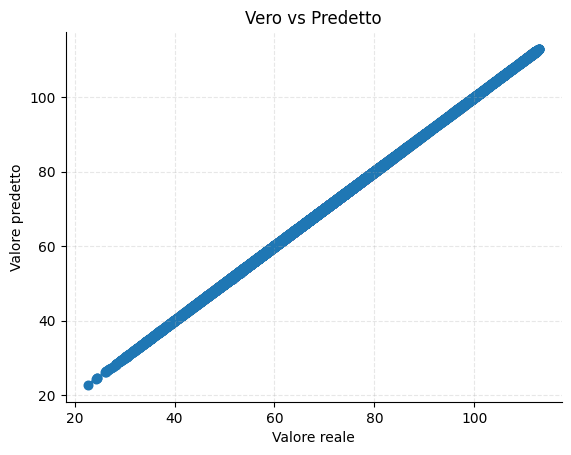

In [6]:
for degree in DEGREE:
    model = PolynomialRegression(degree=degree)
    model.fit(X_train, y_train)
    print("\n"+"Degree ", degree)
    model.evaluate_regression(X_test, y_test)

    y_pred = model.predict(X_test)

    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle="--"
    )
    plt.xlabel("Valore reale")
    plt.ylabel("Valore predetto")
    plt.title("Vero vs Predetto")
    plt.show()

In [ ]:
train_full=load_dataset(TRAIN_PATH_FULL)
X_train_full = train_full[FEUTURE].values
y_train_full = train_full[TARGET_COL].values

model_try = PolynomialRegression(degree=2)
best_degree,a,b=model_try.tune_degree(X_train_full, y_train_full, degrees=DEGREE, cv=5, metric="rmse")

In [7]:
model = PolynomialRegression(degree=3)
if os.path.exists(OUTPUT_PATH+MODEL_PATH):
    model= joblib.load(OUTPUT_PATH+MODEL_PATH)
else:
  model.fit(X_train, y_train)
  os.makedirs(OUTPUT_PATH, exist_ok=True)
  joblib.dump(model, OUTPUT_PATH + MODEL_PATH)

In [8]:
if os.path.exists( not OUTPUT_PATH+RESIDUI_CSV):
    model.compute_residuals(X_train,y_train,path=OUTPUT_PATH)

In [10]:
residui = load_dataset(OUTPUT_PATH + RESIDUI_CSV)

test_row = test_df.iloc[223]
test_x = test_row[FEUTURE].to_frame().T
test_y_true =(test_row["trq_measured"] / test_row["trq_target"] - 1) * 100
target_pred = model.predict(test_x)[0]
trq_margin_pred = (test_row["trq_measured"]/ target_pred - 1) * 100

rows = []
for m in range(ITERATIONS):
    residual = float(residui.sample(n=1)["residual"].iloc[0])
    rows.append({"trq_target_probability": target_pred + residual})

distribution = pd.DataFrame(rows)
distribution["trq_margin"] = (test_row["trq_measured"] / distribution["trq_target_probability"] - 1) * 100
distribution.head()

,trq_target_probability,trq_margin
0,74.428271,2.917883
1,74.409502,2.943841
2,74.427864,2.918444
3,74.428242,2.917922
4,74.427674,2.918708


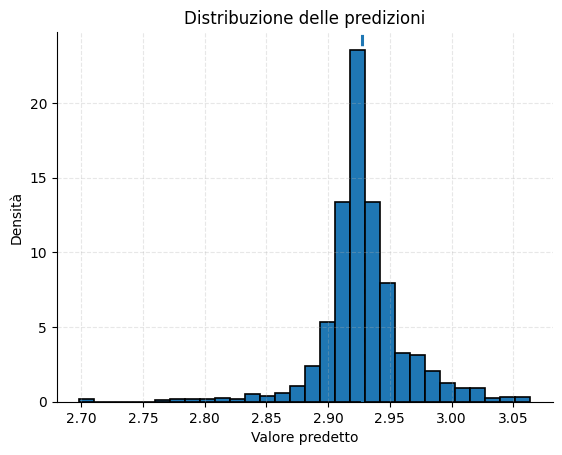

In [11]:
plt.figure()
plt.hist(distribution["trq_margin"], bins=30, density=True)
plt.axvline(trq_margin_pred, linestyle="--", label="Predizione puntuale")
plt.xlabel("Valore predetto")
plt.xlabel("Valore predetto")
plt.ylabel("Densità")
plt.title("Distribuzione delle predizioni")
plt.show()

In [13]:
ranking,best= fit_rank_pdfs_loglik(distribution["trq_margin"])


=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) t            | loglik=2117.52
02) laplace      | loglik=2106.84
03) cauchy       | loglik=2086.12
04) logistic     | loglik=2038.90
05) beta         | loglik=1930.58
06) norm         | loglik=1927.78
07) lognorm      | loglik=1927.78
08) nakagami     | loglik=1927.55
09) f            | loglik=1927.50
10) chi2         | loglik=1906.65
11) gamma        | loglik=1904.40
12) betaprime    | loglik=1900.47
13) weibull_min  | loglik=1860.67
14) gumbel_r     | loglik=1600.93
15) powerlaw     | loglik=1220.07
16) rayleigh     | loglik=1115.33
17) uniform      | loglik=1007.10
18) expon        | loglik=467.73
19) pareto       | loglik=467.73
20) erlang       | loglik=41.92


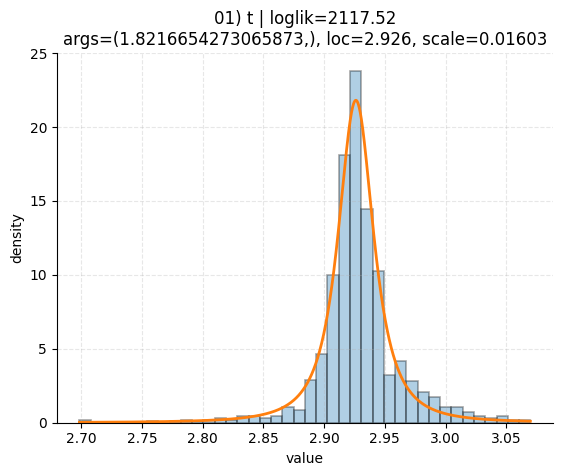

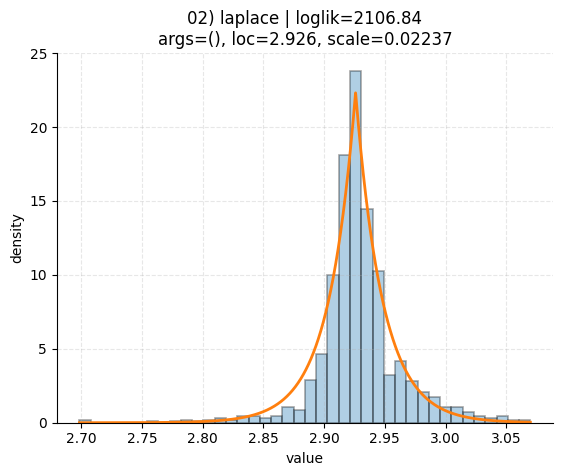

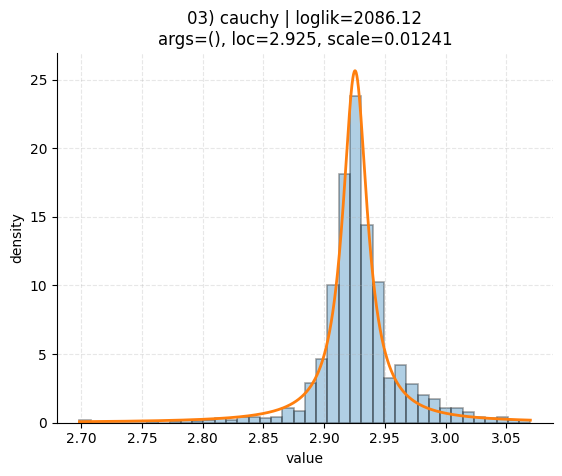

In [14]:
plot_ranked_pdfs(ranking,distribution["trq_margin"])

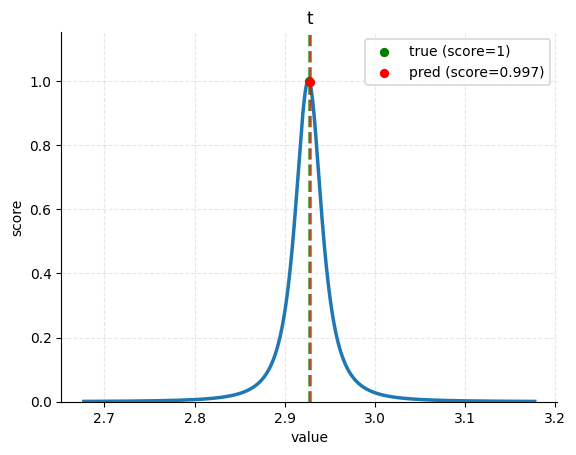

{'pdf_type': 't',
 'true_target': 2.926861276753012,
 'prediction': 2.927453224063359,
 'score_true': 1.0007756010515594,
 'score_pred': 0.9972951180206818,
 'x_range': (2.6771572504081855, 3.1771572504081855)}

In [15]:
plot_pdf_with_true_target(best["pdf_type"],best["pdf_args"],test_y_true,trq_margin_pred)

In [13]:
residual_arr = residui["residual"].astype(float).to_numpy()

pdf_list = ["norm", "t", "cauchy", "laplace", "lognorm", "gamma"]

rng = np.random.default_rng(42)

rows_out = []

pbar = tqdm(range(len(test_df)), desc="Processing test set", unit="row")

for i in pbar:

    test_row = test_df.iloc[i]

    trq_measured = float(test_row["trq_measured"])
    trq_target_true = float(test_row["trq_target"])

    test_x = test_row[FEUTURE].to_frame().T

    test_y_true = (trq_measured / trq_target_true - 1.0) * 100.0

    pbar.set_postfix_str("predicting")
    target_pred = float(model.predict(test_x)[0])
    trq_margin_pred = (trq_measured / target_pred - 1.0) * 100.0

    pbar.set_postfix_str("sampling residuals")
    sampled_res = rng.choice(residual_arr, size=int(ITERATIONS), replace=True)
    trq_target_prob = target_pred + sampled_res

    trq_target_prob = np.where(np.abs(trq_target_prob) < 1e-12, np.nan, trq_target_prob)

    trq_margin_dist = (trq_measured / trq_target_prob - 1.0) * 100.0
    trq_margin_dist = trq_margin_dist[np.isfinite(trq_margin_dist)]


    pbar.set_postfix_str("fitting pdf")
    ranking, best = fit_rank_pdfs_loglik(trq_margin_dist, pdf_list=pdf_list)

    if best is None or best.get("pdf_args") is None:
        continue

    best_pdf = best["pdf_type"]
    best_args = best["pdf_args"]

    pbar.set_postfix_str("scoring")
    score_true = float(get_regression_score(best_pdf, best_args, float(test_y_true)))
    score_pred = float(get_regression_score(best_pdf, best_args, float(trq_margin_pred)))

    out = test_row[FEUTURE].to_dict()
    out.update({
        "idx": i,
        "trq_target_true": trq_target_true,
        "trq_target_pred": target_pred,
        "y_true": float(test_y_true),
        "y_pred": float(trq_margin_pred),
        "best_pdf": best_pdf,
        "best_pdf_args": best_args,
        "best_loglik": float(best.get("loglik", np.nan)),
        "score_true": score_true,
        "score_pred": score_pred,
        "n_mc_used": int(trq_margin_dist.size),
    })

    rows_out.append(out)

pbar.close()

df_report = pd.DataFrame(rows_out)
df_report.head()


/Users/alessandropettinaro/PycharmProjects/PHM_2024_Project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing test set:   0%|          | 2/111394 [00:00<2:41:41, 11.48row/s, fitting pdf]       


=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) laplace      | loglik=1504.59
02) cauchy       | loglik=1496.53
03) t            | loglik=1373.55
04) norm         | loglik=1292.06
05) lognorm      | loglik=1292.06
06) gamma        | loglik=1263.58

=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) t            | loglik=2054.35
02) laplace      | loglik=2026.65
03) cauchy       | loglik=2025.82
04) norm         | loglik=1802.24
05) lognorm      | loglik=1802.24
06) gamma        | loglik=-292.76

=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) cauchy       | loglik=2273.99
02) laplace      | loglik=2255.36
03) t            | loglik=2000.73
04) norm         | loglik=2000.19
05) lognorm      | loglik=1999.69
06) gamma        | loglik=1980.61


Processing test set:   0%|          | 4/111394 [00:00<2:37:04, 11.82row/s, scoring]           


=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) t            | loglik=1926.72
02) cauchy       | loglik=1900.17
03) laplace      | loglik=1890.50
04) norm         | loglik=1621.20
05) lognorm      | loglik=1621.20
06) gamma        | loglik=1537.63

=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) t            | loglik=2119.11
02) laplace      | loglik=2107.15
03) cauchy       | loglik=2085.95
04) norm         | loglik=1921.69
05) lognorm      | loglik=1921.08
06) gamma        | loglik=1913.67

=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) t            | loglik=1965.24
02) cauchy       | loglik=1941.16
03) laplace      | loglik=1930.97
04) norm         | loglik=1683.72
05) lognorm      | loglik=1683.72
06) gamma        | loglik=1633.84


Processing test set:   0%|          | 8/111394 [00:00<2:43:52, 11.33row/s, fitting pdf]       

...


=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) t            | loglik=1792.43
02) cauchy       | loglik=1768.34
03) laplace      | loglik=1756.24
04) norm         | loglik=1519.98
05) lognorm      | loglik=1519.98
06) gamma        | loglik=1487.37

=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) cauchy       | loglik=1739.24
02) laplace      | loglik=1724.30
03) t            | loglik=1596.15
04) norm         | loglik=1480.83
05) lognorm      | loglik=1480.05
06) gamma        | loglik=1343.94


Processing test set:   4%|▍         | 4664/111394 [07:35<3:17:37,  9.00row/s, fitting pdf]       


=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) laplace      | loglik=1907.36
02) cauchy       | loglik=1900.43
03) t            | loglik=1850.39
04) norm         | loglik=1673.08
05) lognorm      | loglik=1673.08
06) gamma        | loglik=1576.00

=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) laplace      | loglik=1766.81
02) cauchy       | loglik=1763.29
03) t            | loglik=1555.33
04) norm         | loglik=1554.65
05) lognorm      | loglik=1553.92
06) gamma        | loglik=1531.38


Processing test set:   4%|▍         | 4664/111394 [07:35<2:53:43, 10.24row/s, fitting pdf]


KeyboardInterrupt: 

In [ ]:
save_processed_dataset(df_report, path=OUTPUT_PATH+"report_test.csv")